In [1]:
# importing all requires libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
# loading the dataset
df = pd.read_csv("customer_reviews.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (90, 2)


,review,sentiment
0,The product quality is excellent and exceeded ...,Positive
1,I loved the service and the delivery was very ...,Positive
2,Amazing product with great quality and beautif...,Positive
3,The customer support team was helpful and frie...,Positive
4,I am very happy with my purchase and would rec...,Positive


In [3]:
# Dataset Information
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Number of rows: 90
Number of columns: 2

Column names:
['review', 'sentiment']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     90 non-null     object
 1   sentiment  90 non-null     object
dtypes: object(2)
memory usage: 1.5+ KB


In [4]:
# Missing Values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
review       0
sentiment    0
dtype: int64


In [5]:
# Sentiment Distribution
print("Sentiment Distribution:")
print(df["sentiment"].value_counts())

Sentiment Distribution:
sentiment
Positive    30
Negative    30
Neutral     30
Name: count, dtype: int64


In [6]:
# Five Sample Customer Reviews
print("Five Sample Customer Reviews:\n")
display(df.sample(5, random_state=42))

Five Sample Customer Reviews:



,review,sentiment
40,The item broke shortly after I received it.,Negative
22,I would definitely buy this product again.,Positive
55,The service was slow and frustrating.,Negative
70,The product is black and made of plastic.,Neutral
0,The product quality is excellent and exceeded ...,Positive


In [7]:
# Data Preprocessing
def clean_text(text):
    # Convert text to lowercase
    text = str(text).lower()
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)
    
    # Remove leading and trailing spaces
    text = text.strip()
    
    return text

In [8]:
# Apply the cleaning function to the review column
df["clean_review"] = df["review"].apply(clean_text)

display(df[["review", "clean_review"]].head(10))

,review,clean_review
0,The product quality is excellent and exceeded ...,the product quality is excellent and exceeded ...
1,I loved the service and the delivery was very ...,i loved the service and the delivery was very ...
2,Amazing product with great quality and beautif...,amazing product with great quality and beautif...
3,The customer support team was helpful and frie...,the customer support team was helpful and frie...
4,I am very happy with my purchase and would rec...,i am very happy with my purchase and would rec...
5,The package arrived early and everything was p...,the package arrived early and everything was p...
6,Excellent value for money and very reliable pr...,excellent value for money and very reliable pr...
7,The product works perfectly and is easy to use.,the product works perfectly and is easy to use
8,Fantastic service and quick delivery.,fantastic service and quick delivery
9,I am impressed with the quality of this product.,i am impressed with the quality of this product


In [9]:
# Splitting the dataset into features and labels
X = df["clean_review"]
y = df["sentiment"]

print("Features (X):")
display(X.head())

print("\nLabels (y):")
display(y.head())

Features (X):


0    the product quality is excellent and exceeded ...
1    i loved the service and the delivery was very ...
2    amazing product with great quality and beautif...
3    the customer support team was helpful and frie...
4    i am very happy with my purchase and would rec...
Name: clean_review, dtype: object


Labels (y):


0    Positive
1    Positive
2    Positive
3    Positive
4    Positive
Name: sentiment, dtype: object

In [10]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 72
Testing samples: 18


In [11]:
# Feature Extraction using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (72, 520)
Testing TF-IDF shape: (18, 520)


In [12]:
# Transform the training and testing data using the fitted TF-IDF vectorizer
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (72, 520)
Testing TF-IDF shape: (18, 520)


In [13]:
# Displaying the first 30 TF-IDF features
feature_names = tfidf.get_feature_names_out()

print("Number of TF-IDF features:", len(feature_names))

print("\nFirst 30 features:")
print(feature_names[:30])

Number of TF-IDF features: 520

First 30 features:
['about' 'about my' 'address' 'after' 'after few' 'after two' 'again' 'am'
 'am extremely' 'am impressed' 'am satisfied' 'am unhappy' 'am very' 'and'
 'and arrived' 'and customer' 'and disappointing' 'and does'
 'and efficient' 'and everything' 'and exceeded' 'and excellent'
 'and fast' 'and fixed' 'and friendly' 'and frustrating' 'and great'
 'and its' 'and low' 'and made']


In [14]:
# Model Training
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    C=5,
    max_iter=2000,
    solver="liblinear"
)

model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


c:\Users\gumpe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


In [15]:
# Evaluating the model
model.fit(X_train_tfidf, y_train)

print("Model training completed successfully!")

Model training completed successfully!


c:\Users\gumpe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


In [16]:
# Making Predictions
y_pred = model.predict(X_test_tfidf)

print("Predictions generated successfully!")
print(y_pred)

Predictions generated successfully!
['Positive' 'Negative' 'Positive' 'Neutral' 'Neutral' 'Neutral' 'Negative'
 'Neutral' 'Positive' 'Negative' 'Negative' 'Negative' 'Neutral'
 'Positive' 'Negative' 'Neutral' 'Negative' 'Neutral']


In [17]:
# Evaluating the model
results = pd.DataFrame({
    "Customer Review": X_test,
    "Actual Sentiment": y_test,
    "Predicted Sentiment": y_pred
})

display(results)

,Customer Review,Actual Sentiment,Predicted Sentiment
11,great experience from ordering to delivery,Positive,Positive
40,the item broke shortly after i received it,Negative,Negative
74,the delivery was completed this morning,Neutral,Positive
69,i received the package in the afternoon,Neutral,Neutral
14,the quality is outstanding for the price,Positive,Neutral
87,the package was received without any missing i...,Neutral,Neutral
50,the quality is far worse than i expected,Negative,Negative
7,the product works perfectly and is easy to use,Positive,Neutral
6,excellent value for money and very reliable pr...,Positive,Positive
44,i received a defective product,Negative,Negative


In [18]:
# Calculating Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 0.7777777777777778
Model Accuracy: 77.78%


In [19]:
# Displaying the classification report
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Classification Report:

              precision    recall  f1-score   support

    Negative       0.86      1.00      0.92         6
     Neutral       0.71      0.83      0.77         6
    Positive       0.75      0.50      0.60         6

    accuracy                           0.78        18
   macro avg       0.77      0.78      0.76        18
weighted avg       0.77      0.78      0.76        18



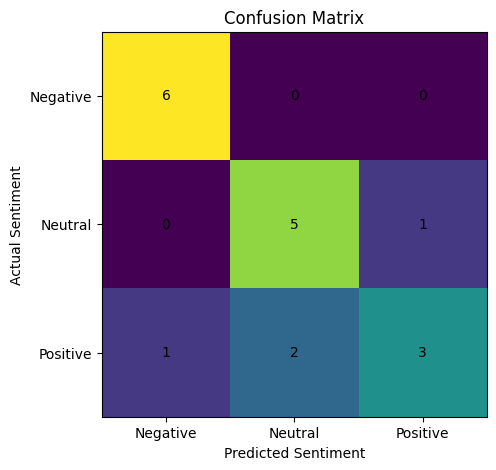

In [20]:
# Displaying the confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Negative", "Neutral", "Positive"]
)

# Display confusion matrix
plt.figure(figsize=(7, 5))
plt.imshow(cm)

plt.xticks(
    range(3),
    ["Negative", "Neutral", "Positive"]
)

plt.yticks(
    range(3),
    ["Negative", "Neutral", "Positive"]
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Confusion Matrix")

# Add numbers inside the matrix
for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [21]:
# Displaying New Customer Reviews
new_reviews = [
    "Amazing product, I really loved the quality!",
    "The product is terrible and stopped working.",
    "The package arrived today."
]

print("New Customer Reviews:")

for review in new_reviews:
    print("-", review)

New Customer Reviews:
- Amazing product, I really loved the quality!
- The product is terrible and stopped working.
- The package arrived today.


In [22]:
# Making Predictions on New Reviews
new_reviews_clean = [
    clean_text(review)
    for review in new_reviews
]

new_reviews_tfidf = tfidf.transform(
    new_reviews_clean
)

new_predictions = model.predict(
    new_reviews_tfidf
)

prediction_results = pd.DataFrame({
    "Customer Review": new_reviews,
    "Predicted Sentiment": new_predictions
})

display(prediction_results)

,Customer Review,Predicted Sentiment
0,"Amazing product, I really loved the quality!",Positive
1,The product is terrible and stopped working.,Negative
2,The package arrived today.,Neutral
